# Custom Method Registration Stress Test (User-Friendly)

This notebook runs custom pruning-method registration with backend-heavy abstraction:

- You define method math
- You register with `@register_method(...)`
- Backend handles tracing, data collection, masking, surgery, and most utilities


## Literature Methods Covered (Registration Stress Set)

Methods tested in this notebook via custom registration:

1. **custom_l2** (weight L2 norm, configurable sum/RMS)
2. **chip** (channel independence via nuclear-norm change)
3. **custom_entropy** (local entropy)
4. **custom_hrank** (rank-based)
5. **custom_class_entropy** (class-aware entropy)
6. **custom_spectral_energy** (spectral criterion)
7. **custom_nisp** (global propagation-style)
8. **custom_senpis** (class-aware global)
9. **custom_tis** (class-aware Taylor style)
10. **custom_reprune** (redundancy clustering style)
11. **custom_thinet** (next-layer reconstruction style)

Note: bundled package methods are intentionally minimal; this notebook is where non-bundled methods are stress-tested.


In [10]:
# --- PHASE 0: BOOTLOADER (Editable Install + Python 3.12 Fix) ---
import sys, os, importlib

# 1. Python 3.12 Fix: Ensure setuptools is fresh for editable installs
!pip install -q --upgrade setuptools pip

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)

    project_folder_name = "activation-based-pruning"
    base_paths = ["/content/drive/Othercomputers", "/content/drive/MyDrive"]
    project_path = None

    for base in base_paths:
        if os.path.exists(base):
            for root, dirs, files in os.walk(base):
                if project_folder_name in dirs: 
                    project_path = os.path.join(root, project_folder_name); break
        if project_path: break

    if project_path:
        os.chdir(project_path)
        src_path = os.path.join(project_path, "src")
        if src_path not in sys.path: sys.path.insert(0, src_path)
        
        # 2. Restore Editable Install
        !pip install -e .
        
        # 3. Load autoreload BEFORE importing the package (3.12 stability fix)
        try:
            try:
                import imp
            except ImportError:
                from types import ModuleType
                import importlib
                imp = ModuleType('imp')
                imp.reload = importlib.reload
                sys.modules['imp'] = imp
                print("🛠️ Applied Python 3.12 'imp' shim")

            %load_ext autoreload
            %autoreload 2
            import reducnn
            print(f"✅ System Ready! ReduCNN {reducnn.__version__} loaded from: {reducnn.__file__}")
        except Exception as e: print(f"⚠️ Package import failed: {e}")
except ImportError: print("Running in Local Environment (Non-Colab)")

Mounted at /content/drive
Obtaining file:///content/drive/Othercomputers/My%20laptop/activation-based-pruning
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ReduCNN (pyproject.toml) ... done
  Created wheel for ReduCNN: filename=reducnn-0.6.6-0.editable-py3-none-any.whl size=3825 sha256=e7c943f626df45bcd4a8e014ffd4f232dce1386f3bdb0738df32ea88c9980916
  Stored in directory: /tmp/pip-ephem-wheel-cache-t4l_ik7r/wheels/95/7c/d1/d047f244a296442b073873e350be16b18b7495b817b0632d15
Successfully built ReduCNN
  Attempting uninstall: ReduCNN
    Found existing installation: ReduCNN 0.6.6
    Uninstalling ReduCNN-0.6.6:
      Successfully uninstalled ReduCNN-0.6.6


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ System Ready! ReduCNN 0.6.6 loaded from: /content/drive/Othercomputers/My laptop/activation-based-pruning/src/reducnn/__init__.py


In [11]:
# Core setup (user-friendly)
import os
import time
import gc
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from reducnn.backends.factory import get_adapter
from reducnn.pruner import ReduCNNPruner, register_method
from reducnn.visualization import (
    plot_layer_sensitivity,
    plot_metrics_comparison,
    plot_training_history,
    plot_rank_correlation,
    plot_score_distributions,
    plot_decision_agreement,
    plot_inference_gallery,
)

SAVE_ROOT = Path("saved_models")
DATASET_KEY = "cifar-10"
CLASS_NAMES = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
RUN_STAMP = time.strftime("%Y%m%d_%H%M%S")

# --- 1) Choose one preset ---
# quick: fastest smoke test
# balanced: recommended for regular experimentation
# full: slower, stronger calibration coverage
EXPERIMENT_PRESET = "balanced"  # quick | balanced | full

# --- 2) Choose model target ---
# Supported: resnet18, vgg16, densenet121, mobilenet_v2
MODEL_TARGET = "resnet18"

# --- 3) Pruning level ---
PRUNE_RATIO = 0.30

# --- 4) Pretrained policy ---
REQUIRE_PRETRAINED_TORCH = True
REQUIRE_PRETRAINED_KERAS = False

# --- 5) Checkpoint persistence policy ---
AUTO_TRAIN_BASELINE_IF_MISSING = True
SAVE_BASELINE_WHEN_MISSING = True
SAVE_RAW_PRUNED_CHECKPOINTS = True
SAVE_HEALED_CHECKPOINTS = True

# --- 6) Baseline bootstrap policy (full training when missing) ---
BASELINE_BOOTSTRAP_USE_FULL_DATA = True
BASELINE_BOOTSTRAP_LR = 1e-3
BASELINE_MIN_ACCEPTABLE_ACC = 60.0
BASELINE_RANDOM_SEED = 42

# --- 7) Deep analysis / healing visuals ---
RUN_DEEP_ANALYSIS = True
ANALYSIS_BACKENDS = ["pytorch", "keras"]
ANALYSIS_METHOD = "custom_nisp"
ANALYSIS_COMPARE_METHODS = ["custom_l2", "custom_nisp", "custom_senpis", "custom_tis"]

# Preset table (single place controlling runtime/quality tradeoff)
_PRESET_CFG = {
    "quick": {
        "calib_batches": 1,
        "max_samples": 256,
        "batch_size": 64,
        "chip_max_spatial": 16,
        "finetune_epochs": 1,
        "ft_train_samples": 1024,
        "ft_val_samples": 512,
        "ft_test_samples": 1024,
        "baseline_bootstrap_epochs": 4,
    },
    "balanced": {
        "calib_batches": 2,
        "max_samples": 1024,
        "batch_size": 64,
        "chip_max_spatial": 24,
        "finetune_epochs": 3,
        "ft_train_samples": 4096,
        "ft_val_samples": 1000,
        "ft_test_samples": 2000,
        "baseline_bootstrap_epochs": 15,
    },
    "full": {
        "calib_batches": 4,
        "max_samples": 2048,
        "batch_size": 64,
        "chip_max_spatial": 32,
        "finetune_epochs": 6,
        "ft_train_samples": 10000,
        "ft_val_samples": 2000,
        "ft_test_samples": 5000,
        "baseline_bootstrap_epochs": 30,
    },
}
if EXPERIMENT_PRESET not in _PRESET_CFG:
    raise ValueError(f"Unknown EXPERIMENT_PRESET='{EXPERIMENT_PRESET}'. Use one of: {list(_PRESET_CFG.keys())}")

CALIB_BATCHES = int(_PRESET_CFG[EXPERIMENT_PRESET]["calib_batches"])
MAX_SAMPLES = int(_PRESET_CFG[EXPERIMENT_PRESET]["max_samples"])
BATCH_SIZE = int(_PRESET_CFG[EXPERIMENT_PRESET]["batch_size"])
CHIP_MAX_SPATIAL = int(_PRESET_CFG[EXPERIMENT_PRESET]["chip_max_spatial"])
FINETUNE_EPOCHS = int(_PRESET_CFG[EXPERIMENT_PRESET]["finetune_epochs"])
FT_TRAIN_SAMPLES = int(_PRESET_CFG[EXPERIMENT_PRESET]["ft_train_samples"])
FT_VAL_SAMPLES = int(_PRESET_CFG[EXPERIMENT_PRESET]["ft_val_samples"])
FT_TEST_SAMPLES = int(_PRESET_CFG[EXPERIMENT_PRESET]["ft_test_samples"])
BASELINE_BOOTSTRAP_EPOCHS = int(_PRESET_CFG[EXPERIMENT_PRESET]["baseline_bootstrap_epochs"])

TORCH_MODEL_REQUEST = MODEL_TARGET
KERAS_MODEL_REQUEST = MODEL_TARGET

CUSTOM_METHODS = [
    "custom_l2",
    "chip",
    "custom_entropy",
    "custom_hrank",
    "custom_class_entropy",
    "custom_spectral_energy",
    "custom_nisp",
    "custom_senpis",
    "custom_tis",
    "custom_reprune",
    "custom_thinet",
]

GLOBAL_METHODS = {"chip", "custom_nisp", "custom_senpis", "custom_tis", "custom_reprune", "custom_thinet"}

EPS = 1e-12
BINS = 24

print("=== Experiment Config ===")
print(f"Run stamp: {RUN_STAMP}")
print(f"Preset: {EXPERIMENT_PRESET}")
print(f"Model target: {MODEL_TARGET}")
print(f"Prune ratio: {PRUNE_RATIO}")
print(f"Calibration: batches={CALIB_BATCHES}, max_samples={MAX_SAMPLES}, batch_size={BATCH_SIZE}")
print(f"Recovery: finetune_epochs={FINETUNE_EPOCHS}, train/val/test={FT_TRAIN_SAMPLES}/{FT_VAL_SAMPLES}/{FT_TEST_SAMPLES}")
print(f"Baseline bootstrap epochs: {BASELINE_BOOTSTRAP_EPOCHS} (full_data={BASELINE_BOOTSTRAP_USE_FULL_DATA})")
print(f"Baseline bootstrap lr: {BASELINE_BOOTSTRAP_LR}")
print(f"CHIP max spatial: {CHIP_MAX_SPATIAL}")
print(f"Require pretrained torch={REQUIRE_PRETRAINED_TORCH}, keras={REQUIRE_PRETRAINED_KERAS}")
print(f"Persistence: baseline_if_missing={SAVE_BASELINE_WHEN_MISSING}, raw={SAVE_RAW_PRUNED_CHECKPOINTS}, healed={SAVE_HEALED_CHECKPOINTS}")
print("Methods:", CUSTOM_METHODS)


=== Experiment Config ===
Run stamp: 20260324_112655
Preset: balanced
Model target: resnet18
Prune ratio: 0.3
Calibration: batches=2, max_samples=1024, batch_size=64
Recovery: finetune_epochs=3, train/val/test=4096/1000/2000
Baseline bootstrap epochs: 15 (full_data=True)
Baseline bootstrap lr: 0.001
CHIP max spatial: 24
Require pretrained torch=True, keras=False
Persistence: baseline_if_missing=True, raw=True, healed=True
Methods: ['custom_l2', 'chip', 'custom_entropy', 'custom_hrank', 'custom_class_entropy', 'custom_spectral_energy', 'custom_nisp', 'custom_senpis', 'custom_tis', 'custom_reprune', 'custom_thinet']


In [12]:
# Helpers: checkpoints + data

def _latest_file(paths):
    files = [p for p in paths if p.exists()]
    if not files:
        return None
    return str(sorted(files, key=lambda p: p.stat().st_mtime, reverse=True)[0])


def _ckpt_ext(backend: str) -> str:
    backend = backend.lower().strip()
    return ".pth" if backend == "pytorch" else ".weights.h5"


def build_checkpoint_path(stage: str, backend: str, model_name: str, method: str = None,
                          suffix: str = None, run_stamp: str = RUN_STAMP, dataset_key: str = DATASET_KEY):
    root = SAVE_ROOT / stage / backend / dataset_key / model_name
    if method:
        root = root / method
    root.mkdir(parents=True, exist_ok=True)

    fname = f"{run_stamp}_{backend}_{model_name}"
    if method:
        fname += f"_{method}"
    if suffix:
        fname += f"_{suffix}"
    fname += _ckpt_ext(backend)
    return str(root / fname)


def find_latest_baseline_checkpoint(backend: str, model_request: str, dataset_key: str = DATASET_KEY):
    backend = backend.lower().strip()
    model_l = str(model_request).lower().strip()
    if backend == "pytorch":
        exts = [".pth", ".pt"]
        aliases = {
            "resnet18": ["resnet18"],
            "vgg16": ["vgg16"],
            "densenet121": ["densenet121", "densenet", "desnsenet121"],
            "mobilenet_v2": ["mobilenet_v2", "mobilenetv2", "mobilenet"],
        }
    else:
        exts = [".weights.h5", ".h5"]
        aliases = {
            "resnet18": ["resnet18"],
            "vgg16": ["vgg16"],
            "densenet121": ["densenet121", "densenet"],
            "mobilenet_v2": ["mobilenet_v2", "mobilenetv2", "mobilenet"],
            "resnet": ["resnet", "resnet18"],
            "mobilenet": ["mobilenet", "mobilenet_v2"],
            "densenet": ["densenet", "densenet121"],
        }

    exact_dir = SAVE_ROOT / "baselines" / backend / dataset_key / model_request
    exact_candidates = []
    for ext in exts:
        exact_candidates.extend(exact_dir.glob(f"*{ext}"))
    exact = _latest_file(exact_candidates)
    if exact:
        return exact

    scan_root = SAVE_ROOT / "baselines" / backend / dataset_key
    if not scan_root.exists():
        return None

    all_candidates = []
    for ext in exts:
        all_candidates.extend(scan_root.rglob(f"*{ext}"))
    if not all_candidates:
        return None

    cand_aliases = aliases.get(model_l, [model_l])

    def _rank_key(p):
        s = str(p).lower().replace('/', '\\')
        alias_hits = [i for i, a in enumerate(cand_aliases) if a in s]
        has_any = len(alias_hits) > 0
        has_exact = model_l in s
        has_exact_dir = f"\\{model_l}\\" in s
        alias_idx = min(alias_hits) if alias_hits else 999
        return (
            not has_any,
            not has_exact_dir,
            not has_exact,
            alias_idx,
            -p.stat().st_mtime,
        )

    ranked = sorted(all_candidates, key=_rank_key)
    if not ranked:
        return None
    if not any(a in str(ranked[0]).lower() for a in cand_aliases):
        return None
    return str(ranked[0])


def make_torch_calib_loader(max_samples: int = MAX_SAMPLES, batch_size: int = BATCH_SIZE):
    import torchvision
    import torchvision.transforms as transforms
    from torch.utils.data import DataLoader, Subset

    tfm = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])
    trainset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=tfm)
    idx = list(range(min(max_samples, len(trainset))))
    subset = Subset(trainset, idx)
    return DataLoader(subset, batch_size=batch_size, shuffle=False)


def make_keras_calib_loader(max_samples: int = MAX_SAMPLES, batch_size: int = BATCH_SIZE):
    import tensorflow as tf

    (x_train, y_train), _ = tf.keras.datasets.cifar10.load_data()
    x = x_train[:max_samples].astype("float32") / 255.0
    y = y_train[:max_samples].astype("int32").reshape(-1)
    ds = tf.data.Dataset.from_tensor_slices((x, y)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


def make_torch_baseline_loaders(batch_size: int = BATCH_SIZE, val_ratio: float = 0.1, seed: int = BASELINE_RANDOM_SEED):
    import torchvision
    import torchvision.transforms as transforms
    from torch.utils.data import DataLoader, Subset

    train_tfm = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])
    eval_tfm = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])

    train_aug = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=train_tfm)
    train_eval = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=eval_tfm)
    testset = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=eval_tfm)

    n = len(train_aug)
    rng = np.random.default_rng(int(seed))
    idx = rng.permutation(n)
    n_val = max(1, int(val_ratio * n))
    val_idx = idx[:n_val].tolist()
    train_idx = idx[n_val:].tolist()

    train_loader = DataLoader(Subset(train_aug, train_idx), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(Subset(train_eval, val_idx), batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader


def make_keras_baseline_loaders(batch_size: int = BATCH_SIZE, val_ratio: float = 0.1, seed: int = BASELINE_RANDOM_SEED):
    import tensorflow as tf

    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
    x_train = x_train.astype("float32") / 255.0
    y_train = y_train.astype("int32").reshape(-1)
    x_test = x_test.astype("float32") / 255.0
    y_test = y_test.astype("int32").reshape(-1)

    n = len(x_train)
    rng = np.random.default_rng(int(seed))
    idx = rng.permutation(n)
    n_val = max(1, int(val_ratio * n))
    val_idx = idx[:n_val]
    train_idx = idx[n_val:]

    x_tr, y_tr = x_train[train_idx], y_train[train_idx]
    x_va, y_va = x_train[val_idx], y_train[val_idx]

    train_ds = tf.data.Dataset.from_tensor_slices((x_tr, y_tr)).shuffle(min(len(x_tr), 10000), seed=int(seed), reshuffle_each_iteration=True)

    def _augment(x, y):
        x = tf.image.resize_with_crop_or_pad(x, 36, 36)
        x = tf.image.random_crop(x, size=(32, 32, 3))
        x = tf.image.random_flip_left_right(x)
        return x, y

    train_ds = train_ds.map(_augment, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    val_ds = tf.data.Dataset.from_tensor_slices((x_va, y_va)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return train_ds, val_ds, test_ds


def make_torch_recovery_loaders(train_samples: int = FT_TRAIN_SAMPLES,
                                val_samples: int = FT_VAL_SAMPLES,
                                test_samples: int = FT_TEST_SAMPLES,
                                batch_size: int = BATCH_SIZE):
    import torchvision
    import torchvision.transforms as transforms
    from torch.utils.data import DataLoader, Subset

    tfm = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])

    trainset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=tfm)
    testset = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=tfm)

    t_end = min(train_samples, len(trainset))
    v_start = t_end
    v_end = min(v_start + val_samples, len(trainset))
    te_end = min(test_samples, len(testset))

    train_loader = DataLoader(Subset(trainset, list(range(0, t_end))), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(Subset(trainset, list(range(v_start, v_end))), batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(Subset(testset, list(range(0, te_end))), batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader


def make_keras_recovery_loaders(train_samples: int = FT_TRAIN_SAMPLES,
                                val_samples: int = FT_VAL_SAMPLES,
                                test_samples: int = FT_TEST_SAMPLES,
                                batch_size: int = BATCH_SIZE):
    import tensorflow as tf

    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
    x_train = x_train.astype("float32") / 255.0
    y_train = y_train.astype("int32").reshape(-1)
    x_test = x_test.astype("float32") / 255.0
    y_test = y_test.astype("int32").reshape(-1)

    t_end = min(train_samples, len(x_train))
    v_start = t_end
    v_end = min(v_start + val_samples, len(x_train))
    te_end = min(test_samples, len(x_test))

    train_ds = tf.data.Dataset.from_tensor_slices((x_train[:t_end], y_train[:t_end])).shuffle(min(t_end, 4096)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    val_ds = tf.data.Dataset.from_tensor_slices((x_train[v_start:v_end], y_train[v_start:v_end])).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    test_ds = tf.data.Dataset.from_tensor_slices((x_test[:te_end], y_test[:te_end])).batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return train_ds, val_ds, test_ds


def ensure_baseline_checkpoint(adapter, backend: str, model_name: str, found_ckpt: str,
                               input_shape, num_classes: int,
                               require_pretrained: bool):
    backend = backend.lower().strip()
    if found_ckpt and os.path.exists(found_ckpt):
        return found_ckpt, False

    if require_pretrained and not AUTO_TRAIN_BASELINE_IF_MISSING:
        raise FileNotFoundError(
            f"No pretrained baseline checkpoint found for {model_name} under {SAVE_ROOT}/baselines/{backend}/{DATASET_KEY}"
        )

    if not AUTO_TRAIN_BASELINE_IF_MISSING:
        return found_ckpt, False

    print(f"[baseline] Missing baseline for {backend}:{model_name}. Training full baseline...")
    model = adapter.get_model(model_name, input_shape=input_shape, num_classes=num_classes, pretrained=False)

    if BASELINE_BOOTSTRAP_USE_FULL_DATA:
        if backend == "pytorch":
            tr, va, te = make_torch_baseline_loaders(batch_size=BATCH_SIZE)
        else:
            tr, va, te = make_keras_baseline_loaders(batch_size=BATCH_SIZE)
    else:
        if backend == "pytorch":
            tr, va, te = make_torch_recovery_loaders()
        else:
            tr, va, te = make_keras_recovery_loaders()

    if BASELINE_BOOTSTRAP_EPOCHS > 0:
        if backend == "pytorch":
            old_lr = float(adapter.config.get("lr", 3e-4))
            adapter.config["lr"] = float(BASELINE_BOOTSTRAP_LR)
            adapter.train(
                model,
                tr,
                epochs=BASELINE_BOOTSTRAP_EPOCHS,
                val_loader=va,
                name=f"{backend}_{model_name}_baseline_bootstrap",
                plot=False,
            )
            adapter.config["lr"] = old_lr
        else:
            import tensorflow as tf
            model.compile(
                optimizer=tf.keras.optimizers.Adam(learning_rate=float(BASELINE_BOOTSTRAP_LR)),
                loss="sparse_categorical_crossentropy",
                metrics=["accuracy"],
            )
            adapter.train(
                model,
                tr,
                epochs=BASELINE_BOOTSTRAP_EPOCHS,
                val_loader=va,
                name=f"{backend}_{model_name}_baseline_bootstrap",
                plot=False,
            )

    try:
        base_acc = float(adapter.evaluate(model, te))
        print(f"[baseline] Trained baseline test accuracy: {base_acc:.2f}%")
        if base_acc < float(BASELINE_MIN_ACCEPTABLE_ACC):
            print(f"[baseline][warn] Accuracy {base_acc:.2f}% < target {BASELINE_MIN_ACCEPTABLE_ACC:.2f}%. Consider more epochs.")
    except Exception as e:
        print(f"[baseline][warn] Could not evaluate baseline accuracy: {type(e).__name__}: {e}")

    if SAVE_BASELINE_WHEN_MISSING:
        save_path = build_checkpoint_path(
            stage="baselines",
            backend=backend,
            model_name=model_name,
            suffix="baseline",
            run_stamp=RUN_STAMP,
        )
        adapter.save_checkpoint(model, save_path)
        print(f"[baseline] Saved: {save_path}")
        return save_path, True

    return found_ckpt, True


def _mask_keep_stats(masks):
    if not masks:
        return 0, 0.0, 0.0
    keep = [float(np.mean(np.asarray(v, dtype=np.float64))) for v in masks.values() if np.asarray(v).size > 0]
    if not keep:
        return len(masks), 0.0, 0.0
    return len(masks), float(np.mean(keep)), float(np.min(keep))

In [13]:
# --- Custom methods: backend does heavy lifting, methods focus on math ---


def _tools(kwargs):
    t = kwargs.get("tools", None)
    if t is None:
        raise ValueError("Backend tools were not provided. Upgrade reducers backend integration.")
    return t


def _max_batches(kwargs):
    return int(kwargs.get("calib_batches", kwargs.get("prune_batches", CALIB_BATCHES)))


@register_method("custom_l2", framework="torch")
@register_method("custom_l2", framework="keras")
def custom_l2_score(layer, **kwargs):
    tools = _tools(kwargs)
    mode = str(kwargs.get("l2_mode", "sum")).lower().strip()
    return np.asarray(tools.weight_l2(layer, mode=mode), dtype=np.float64).reshape(-1)


@register_method("chip", framework="torch")
@register_method("chip", framework="keras")
def chip_score(layer, **kwargs):
    """CHIP registration: backend tools handle Conv/Linear shape details."""
    tools = _tools(kwargs)
    A, _ = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=False)
    if A is None:
        return None
    max_spatial = kwargs.get("chip_max_spatial", None)
    return np.asarray(tools.chip_scores(A, max_spatial=max_spatial), dtype=np.float64).reshape(-1)


@register_method("custom_entropy", framework="torch")
@register_method("custom_entropy", framework="keras")
def custom_entropy_score(layer, **kwargs):
    tools = _tools(kwargs)
    A, _ = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=False)
    if A is None:
        return None
    X = tools.channel_matrix(np.maximum(A, 0.0))
    bins = int(kwargs.get("bins", BINS))
    out = [tools.entropy_1d(X[c], bins=bins, eps=EPS) for c in range(X.shape[0])]
    return np.asarray(out, dtype=np.float64)


@register_method("custom_hrank", framework="torch")
@register_method("custom_hrank", framework="keras")
def custom_hrank_score(layer, **kwargs):
    tools = _tools(kwargs)
    A, _ = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=False)
    if A is None:
        return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
    return np.asarray(tools.rank_scores(A, max_samples=int(kwargs.get("max_rank_samples", 32))), dtype=np.float64).reshape(-1)


@register_method("custom_class_entropy", framework="torch")
@register_method("custom_class_entropy", framework="keras")
def custom_class_entropy_score(layer, **kwargs):
    tools = _tools(kwargs)
    A, Y = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=True)
    if A is None:
        return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)

    NC = tools.pooled_nc(A)
    classes = np.unique(Y)
    if classes.size == 0:
        return np.zeros((NC.shape[1],), dtype=np.float64)

    out = np.zeros((NC.shape[1],), dtype=np.float64)
    bins = int(kwargs.get("bins", BINS))
    for c in range(NC.shape[1]):
        vals = []
        for cls in classes:
            idx = np.where(Y == cls)[0]
            if idx.size:
                vals.append(tools.entropy_1d(NC[idx, c], bins=bins, eps=EPS))
        out[c] = float(np.mean(vals)) if vals else 0.0
    return out


@register_method("custom_spectral_energy", framework="torch")
@register_method("custom_spectral_energy", framework="keras")
def custom_spectral_energy_score(layer, **kwargs):
    tools = _tools(kwargs)
    A, _ = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=False)
    if A is None:
        return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
    return np.asarray(tools.spectral_energy_scores(A, max_samples=int(kwargs.get("max_fft_samples", 32))), dtype=np.float64).reshape(-1)


@register_method("custom_nisp", framework="torch")
@register_method("custom_nisp", framework="keras")
def custom_nisp_score(layer, **kwargs):
    tools = _tools(kwargs)
    lname = kwargs.get("layer_name", None)
    if lname is None:
        return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
    score_map = tools.nisp_score_map(max_batches=_max_batches(kwargs))
    s = score_map.get(lname, None)
    if s is None:
        return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
    return np.asarray(s, dtype=np.float64).reshape(-1)


@register_method("custom_senpis", framework="torch")
@register_method("custom_senpis", framework="keras")
def custom_senpis_score(layer, **kwargs):
    tools = _tools(kwargs)
    mat = tools.classwise_taylor_matrix(layer, max_batches=_max_batches(kwargs))
    if mat is None:
        return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
    base = np.mean(mat, axis=0)
    disc = tools.class_entropy_discriminability(mat)
    return np.asarray(base * (1.0 + disc), dtype=np.float64).reshape(-1)


@register_method("custom_tis", framework="torch")
@register_method("custom_tis", framework="keras")
def custom_tis_score(layer, **kwargs):
    tools = _tools(kwargs)
    mat = tools.classwise_taylor_matrix(layer, max_batches=_max_batches(kwargs))
    if mat is None:
        return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
    pct = float(kwargs.get("tis_percentile", 75.0))
    return np.asarray(tools.tis_threshold_aggregate(mat, percentile=pct), dtype=np.float64).reshape(-1)


@register_method("custom_reprune", framework="torch")
@register_method("custom_reprune", framework="keras")
def custom_reprune_score(layer, **kwargs):
    tools = _tools(kwargs)
    A, _ = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=False)
    if A is None:
        return np.asarray(tools.weight_l2(layer, mode="sum"), dtype=np.float64).reshape(-1)
    return np.asarray(tools.reprune_representative_scores(A), dtype=np.float64).reshape(-1)


@register_method("custom_thinet", framework="torch")
@register_method("custom_thinet", framework="keras")
def custom_thinet_score(layer, **kwargs):
    tools = _tools(kwargs)
    alpha = np.asarray(tools.thinet_alpha(layer), dtype=np.float64).reshape(-1)
    A, _ = tools.collect_layer_outputs(layer, max_batches=_max_batches(kwargs), include_labels=False)
    if A is None:
        return alpha
    return np.asarray(tools.thinet_reconstruction_scores(A, alpha), dtype=np.float64).reshape(-1)


print("Custom methods registered. Backend tools handle tracing, caching, activations, and propagation.")


Custom methods registered. Backend tools handle tracing, caching, activations, and propagation.


## Part A: PyTorch (loop all custom methods, no plots)

In [14]:
# PyTorch run
import torch

torch_cfg = {
    "backend": "pytorch",
    "model_type": TORCH_MODEL_REQUEST,
    "input_shape": (3, 32, 32),
    "num_classes": 10,
    "prune_batches": CALIB_BATCHES,
    "chip_max_spatial": CHIP_MAX_SPATIAL,
    "lr": 1e-4,
    "torch_restore_best": True,
    "torch_reduce_lr_on_plateau": True,
    "torch_lr_patience": 1,
    "torch_lr_reduce_factor": 0.5,
    "torch_min_lr": 1e-6,
}

torch_adapter = get_adapter(None, torch_cfg)
torch_loader = make_torch_calib_loader(max_samples=MAX_SAMPLES, batch_size=BATCH_SIZE)

torch_ckpt = find_latest_baseline_checkpoint("pytorch", TORCH_MODEL_REQUEST)
torch_ckpt, torch_baseline_created = ensure_baseline_checkpoint(
    adapter=torch_adapter,
    backend="pytorch",
    model_name=TORCH_MODEL_REQUEST,
    found_ckpt=torch_ckpt,
    input_shape=(3, 32, 32),
    num_classes=10,
    require_pretrained=REQUIRE_PRETRAINED_TORCH,
)
print("PyTorch baseline checkpoint used:", torch_ckpt)


def _load_torch_baseline():
    m = torch_adapter.get_model(TORCH_MODEL_REQUEST, input_shape=(3, 32, 32), num_classes=10, pretrained=False)
    if torch_ckpt:
        torch_adapter.load_checkpoint(m, torch_ckpt)
    return m


torch_rows = []
for method in CUSTOM_METHODS:
    scope = "global" if method in GLOBAL_METHODS else "local"
    t0 = time.time()
    status, err = "ok", ""
    n_layers, mean_keep, min_keep, duration = 0, 0.0, 0.0, 0.0
    raw_ckpt = ""

    try:
        model = _load_torch_baseline()
        pruner = ReduCNNPruner(method=method, scope=scope, config={"backend": "pytorch", "chip_max_spatial": CHIP_MAX_SPATIAL})
        raw_ckpt = build_checkpoint_path(
            stage="pruned_raw",
            backend="pytorch",
            model_name=TORCH_MODEL_REQUEST,
            method=method,
            suffix="raw",
            run_stamp=RUN_STAMP,
        ) if SAVE_RAW_PRUNED_CHECKPOINTS else None
        pruned_model, masks, duration = pruner.prune_custom_model(
            model,
            torch_loader,
            ratio=PRUNE_RATIO,
            save_pruned_path=raw_ckpt,
        )
        n_layers, mean_keep, min_keep = _mask_keep_stats(masks)
    except Exception as e:
        status, err = "error", f"{type(e).__name__}: {e}"
        raw_ckpt = ""
    finally:
        gc.collect()

    torch_rows.append({
        "backend": "pytorch",
        "model": TORCH_MODEL_REQUEST,
        "method": method,
        "scope": scope,
        "status": status,
        "error": err,
        "layers_scored": int(n_layers),
        "mean_keep_ratio": round(mean_keep, 4),
        "min_keep_ratio": round(min_keep, 4),
        "prune_time_sec": round(duration, 3),
        "wall_time_sec": round(time.time() - t0, 3),
        "baseline_ckpt_used": torch_ckpt or "",
        "baseline_created": bool(torch_baseline_created),
        "raw_pruned_ckpt": raw_ckpt or "",
    })
    print(f"[torch] {method:<22} ({scope}) -> {status}")

pd.DataFrame(torch_rows).sort_values(["status", "method"]).reset_index(drop=True)


PyTorch baseline checkpoint used: saved_models/baselines/pytorch/cifar-10/resnet18/pytorch_resnet18_cifar-10.pth
📥 Importing custom pre-trained model...

--- Executing ReduCNN ---
🌐 Analyzing model topology...
✅ Detected residual architecture with 4 pruning clusters.
🔍 Analyzing model using 'custom_l2' method...
🏗️ Building masks (scope: local, ratio: 0.3)...
✂️ Applying physical surgery...
💾 Saved pruned checkpoint to: saved_models/pruned_raw/pytorch/cifar-10/resnet18/custom_l2/20260324_112655_pytorch_resnet18_custom_l2_raw.pth
[timer] prune took 0.16s
[torch] custom_l2              (local) -> ok
📥 Importing custom pre-trained model...

--- Executing ReduCNN ---
🌐 Analyzing model topology...
✅ Detected residual architecture with 4 pruning clusters.
🔍 Analyzing model using 'chip' method...
🏗️ Building masks (scope: global, ratio: 0.3)...
✂️ Applying physical surgery...
💾 Saved pruned checkpoint to: saved_models/pruned_raw/pytorch/cifar-10/resnet18/chip/20260324_112655_pytorch_resnet18_

,backend,model,method,scope,status,error,layers_scored,mean_keep_ratio,min_keep_ratio,prune_time_sec,wall_time_sec,baseline_ckpt_used,baseline_created,raw_pruned_ckpt
0,pytorch,resnet18,chip,global,ok,,20,0.8531,0.3750,0.082,4.934,saved_models/baselines/pytorch/cifar-10/resnet...,False,saved_models/pruned_raw/pytorch/cifar-10/resne...
1,pytorch,resnet18,custom_class_entropy,local,ok,,20,0.7012,0.6992,0.046,8.036,saved_models/baselines/pytorch/cifar-10/resnet...,False,saved_models/pruned_raw/pytorch/cifar-10/resne...
2,pytorch,resnet18,custom_entropy,local,ok,,20,0.7012,0.6992,0.051,4.690,saved_models/baselines/pytorch/cifar-10/resnet...,False,saved_models/pruned_raw/pytorch/cifar-10/resne...
3,pytorch,resnet18,custom_hrank,local,ok,,20,0.7012,0.6992,0.047,10.056,saved_models/baselines/pytorch/cifar-10/resnet...,False,saved_models/pruned_raw/pytorch/cifar-10/resne...
4,pytorch,resnet18,custom_l2,local,ok,,20,0.7012,0.6992,0.047,0.853,saved_models/baselines/pytorch/cifar-10/resnet...,False,saved_models/pruned_raw/pytorch/cifar-10/resne...
5,pytorch,resnet18,custom_nisp,global,ok,,20,0.8393,0.4160,0.085,0.993,saved_models/baselines/pytorch/cifar-10/resnet...,False,saved_models/pruned_raw/pytorch/cifar-10/resne...
6,pytorch,resnet18,custom_reprune,global,ok,,20,0.8905,0.1895,0.067,4.433,saved_models/baselines/pytorch/cifar-10/resnet...,False,saved_models/pruned_raw/pytorch/cifar-10/resne...
7,pytorch,resnet18,custom_senpis,global,ok,,20,0.8535,0.4473,0.074,4.086,saved_models/baselines/pytorch/cifar-10/resnet...,False,saved_models/pruned_raw/pytorch/cifar-10/resne...
8,pytorch,resnet18,custom_spectral_energy,local,ok,,20,0.7012,0.6992,0.046,13.066,saved_models/baselines/pytorch/cifar-10/resnet...,False,saved_models/pruned_raw/pytorch/cifar-10/resne...
9,pytorch,resnet18,custom_thinet,global,ok,,20,0.8176,0.5371,0.049,2.654,saved_models/baselines/pytorch/cifar-10/resnet...,False,saved_models/pruned_raw/pytorch/cifar-10/resne...


## Part B: Keras (loop all custom methods, no plots)

In [15]:
# Keras run
import tensorflow as tf

keras_cfg = {
    "backend": "keras",
    "model_type": KERAS_MODEL_REQUEST,
    "input_shape": (32, 32, 3),
    "num_classes": 10,
    "prune_batches": CALIB_BATCHES,
    "keras_weights": "none",
    "chip_max_spatial": CHIP_MAX_SPATIAL,
    "keras_lr": 1e-4,
    "keras_restore_best": True,
    "keras_reduce_lr_on_plateau": True,
    "keras_early_stop_patience": 2,
    "keras_lr_patience": 1,
    "keras_lr_reduce_factor": 0.5,
    "keras_min_lr": 1e-6,
}

keras_adapter = get_adapter(None, keras_cfg)
keras_loader = make_keras_calib_loader(max_samples=MAX_SAMPLES, batch_size=BATCH_SIZE)

keras_ckpt = find_latest_baseline_checkpoint("keras", KERAS_MODEL_REQUEST)
keras_ckpt, keras_baseline_created = ensure_baseline_checkpoint(
    adapter=keras_adapter,
    backend="keras",
    model_name=KERAS_MODEL_REQUEST,
    found_ckpt=keras_ckpt,
    input_shape=(32, 32, 3),
    num_classes=10,
    require_pretrained=REQUIRE_PRETRAINED_KERAS,
)
print("Keras baseline checkpoint used:", keras_ckpt)


def _load_keras_baseline():
    m = keras_adapter.get_model(KERAS_MODEL_REQUEST, input_shape=(32, 32, 3), num_classes=10, pretrained=False)
    if keras_ckpt:
        keras_adapter.load_checkpoint(m, keras_ckpt)
    return m


keras_rows = []
for method in CUSTOM_METHODS:
    scope = "global" if method in GLOBAL_METHODS else "local"
    t0 = time.time()
    status, err = "ok", ""
    n_layers, mean_keep, min_keep, duration = 0, 0.0, 0.0, 0.0
    raw_ckpt = ""

    try:
        model = _load_keras_baseline()
        pruner = ReduCNNPruner(method=method, scope=scope, config={"backend": "keras", "chip_max_spatial": CHIP_MAX_SPATIAL})
        raw_ckpt = build_checkpoint_path(
            stage="pruned_raw",
            backend="keras",
            model_name=KERAS_MODEL_REQUEST,
            method=method,
            suffix="raw",
            run_stamp=RUN_STAMP,
        ) if SAVE_RAW_PRUNED_CHECKPOINTS else None
        pruned_model, masks, duration = pruner.prune_custom_model(
            model,
            keras_loader,
            ratio=PRUNE_RATIO,
            save_pruned_path=raw_ckpt,
        )
        n_layers, mean_keep, min_keep = _mask_keep_stats(masks)
    except Exception as e:
        status, err = "error", f"{type(e).__name__}: {e}"
        raw_ckpt = ""
    finally:
        try:
            tf.keras.backend.clear_session()
        except Exception:
            pass
        gc.collect()

    keras_rows.append({
        "backend": "keras",
        "model": KERAS_MODEL_REQUEST,
        "method": method,
        "scope": scope,
        "status": status,
        "error": err,
        "layers_scored": int(n_layers),
        "mean_keep_ratio": round(mean_keep, 4),
        "min_keep_ratio": round(min_keep, 4),
        "prune_time_sec": round(duration, 3),
        "wall_time_sec": round(time.time() - t0, 3),
        "baseline_ckpt_used": keras_ckpt or "",
        "baseline_created": bool(keras_baseline_created),
        "raw_pruned_ckpt": raw_ckpt or "",
    })
    print(f"[keras] {method:<22} ({scope}) -> {status}")

pd.DataFrame(keras_rows).sort_values(["status", "method"]).reset_index(drop=True)


[baseline] Missing baseline for keras:resnet18. Training full baseline...
Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.4346 - loss: 1.5891[train] Epoch 1/15 - loss: 1.3033 - acc: 0.5327 - val_loss: 1.7744 - val_acc: 0.5352
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 91ms/step - accuracy: 0.5327 - loss: 1.3033 - val_accuracy: 0.5352 - val_loss: 1.7744 - learning_rate: 0.0010
Epoch 2/15
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.6890 - loss: 0.8795[train] Epoch 2/15 - loss: 0.8226 - acc: 0.7094 - val_loss: 1.0522 - val_acc: 0.6448
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 74ms/step - accuracy: 0.7094 - loss: 0.8226 - val_accuracy: 0.6448 - val_loss: 1.0522 - learning_rate: 0.0010
Epoch 3/15
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.7579 - loss: 0.6856[train] Epoch 3/15 - loss: 0.6536 - acc: 0.7704 - val_loss: 0.8687 - val_acc: 0.7150
704/704 ━━━━━━━━━━━━━━━━━━━━ 52s 74ms/step - accuracy: 0.7704 - loss: 0.6536 - val_accuracy: 0.7150 - val_loss: 0.8687 - learni

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 126 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


📥 Importing custom pre-trained model...

--- Executing ReduCNN ---
🌐 Analyzing model topology...
✅ Detected residual architecture with 4 pruning clusters.
🔍 Analyzing model using 'custom_l2' method...
🏗️ Building masks (scope: local, ratio: 0.3)...
✂️ Applying physical surgery...
💾 Saved pruned checkpoint to: saved_models/pruned_raw/keras/cifar-10/resnet18/custom_l2/20260324_112655_keras_resnet18_custom_l2_raw.weights.h5
[timer] prune took 0.78s
[keras] custom_l2              (local) -> ok
📥 Importing custom pre-trained model...

--- Executing ReduCNN ---
🌐 Analyzing model topology...
✅ Detected residual architecture with 4 pruning clusters.
🔍 Analyzing model using 'chip' method...
🏗️ Building masks (scope: global, ratio: 0.3)...
✂️ Applying physical surgery...
💾 Saved pruned checkpoint to: saved_models/pruned_raw/keras/cifar-10/resnet18/chip/20260324_112655_keras_resnet18_chip_raw.weights.h5
[timer] prune took 3.77s
[keras] chip                   (global) -> ok
📥 Importing custom pre-

,backend,model,method,scope,status,error,layers_scored,mean_keep_ratio,min_keep_ratio,prune_time_sec,wall_time_sec,baseline_ckpt_used,baseline_created,raw_pruned_ckpt
0,keras,resnet18,chip,global,ok,,20,0.8586,0.4141,0.439,5.542,saved_models/baselines/keras/cifar-10/resnet18...,True,saved_models/pruned_raw/keras/cifar-10/resnet1...
1,keras,resnet18,custom_class_entropy,local,ok,,20,0.7012,0.6992,0.552,9.677,saved_models/baselines/keras/cifar-10/resnet18...,True,saved_models/pruned_raw/keras/cifar-10/resnet1...
2,keras,resnet18,custom_entropy,local,ok,,20,0.7012,0.6992,0.501,6.536,saved_models/baselines/keras/cifar-10/resnet18...,True,saved_models/pruned_raw/keras/cifar-10/resnet1...
3,keras,resnet18,custom_hrank,local,ok,,20,0.7012,0.6992,0.660,16.685,saved_models/baselines/keras/cifar-10/resnet18...,True,saved_models/pruned_raw/keras/cifar-10/resnet1...
4,keras,resnet18,custom_l2,local,ok,,20,0.7012,0.6992,0.492,2.486,saved_models/baselines/keras/cifar-10/resnet18...,True,saved_models/pruned_raw/keras/cifar-10/resnet1...
5,keras,resnet18,custom_nisp,global,ok,,20,0.8613,0.4082,0.582,3.559,saved_models/baselines/keras/cifar-10/resnet18...,True,saved_models/pruned_raw/keras/cifar-10/resnet1...
6,keras,resnet18,custom_reprune,global,ok,,20,0.9018,0.1230,0.475,6.008,saved_models/baselines/keras/cifar-10/resnet18...,True,saved_models/pruned_raw/keras/cifar-10/resnet1...
7,keras,resnet18,custom_senpis,global,ok,,20,0.8630,0.4238,0.464,7.582,saved_models/baselines/keras/cifar-10/resnet18...,True,saved_models/pruned_raw/keras/cifar-10/resnet1...
8,keras,resnet18,custom_spectral_energy,local,ok,,20,0.7012,0.6992,0.481,14.120,saved_models/baselines/keras/cifar-10/resnet18...,True,saved_models/pruned_raw/keras/cifar-10/resnet1...
9,keras,resnet18,custom_thinet,global,ok,,20,0.8178,0.5547,0.624,5.418,saved_models/baselines/keras/cifar-10/resnet18...,True,saved_models/pruned_raw/keras/cifar-10/resnet1...


In [16]:
# Combined summary table (PyTorch + Keras) + save report
all_rows = []
if "torch_rows" in globals():
    all_rows.extend(torch_rows)
if "keras_rows" in globals():
    all_rows.extend(keras_rows)

summary = pd.DataFrame(all_rows).sort_values(["backend", "status", "method"]).reset_index(drop=True)

report_dir = Path("outputs/custom_method_matrix")
report_dir.mkdir(parents=True, exist_ok=True)
ts = time.strftime("%Y%m%d_%H%M%S")
report_path = report_dir / f"notebook_run_{MODEL_TARGET}_{EXPERIMENT_PRESET}_{ts}.csv"
summary.to_csv(report_path, index=False)

print("Saved:", report_path)
summary


Saved: outputs/custom_method_matrix/notebook_run_resnet18_balanced_20260324_114305.csv


,backend,model,method,scope,status,error,layers_scored,mean_keep_ratio,min_keep_ratio,prune_time_sec,wall_time_sec,baseline_ckpt_used,baseline_created,raw_pruned_ckpt
0,keras,resnet18,chip,global,ok,,20,0.8586,0.4141,0.439,5.542,saved_models/baselines/keras/cifar-10/resnet18...,True,saved_models/pruned_raw/keras/cifar-10/resnet1...
1,keras,resnet18,custom_class_entropy,local,ok,,20,0.7012,0.6992,0.552,9.677,saved_models/baselines/keras/cifar-10/resnet18...,True,saved_models/pruned_raw/keras/cifar-10/resnet1...
2,keras,resnet18,custom_entropy,local,ok,,20,0.7012,0.6992,0.501,6.536,saved_models/baselines/keras/cifar-10/resnet18...,True,saved_models/pruned_raw/keras/cifar-10/resnet1...
3,keras,resnet18,custom_hrank,local,ok,,20,0.7012,0.6992,0.660,16.685,saved_models/baselines/keras/cifar-10/resnet18...,True,saved_models/pruned_raw/keras/cifar-10/resnet1...
4,keras,resnet18,custom_l2,local,ok,,20,0.7012,0.6992,0.492,2.486,saved_models/baselines/keras/cifar-10/resnet18...,True,saved_models/pruned_raw/keras/cifar-10/resnet1...
5,keras,resnet18,custom_nisp,global,ok,,20,0.8613,0.4082,0.582,3.559,saved_models/baselines/keras/cifar-10/resnet18...,True,saved_models/pruned_raw/keras/cifar-10/resnet1...
6,keras,resnet18,custom_reprune,global,ok,,20,0.9018,0.1230,0.475,6.008,saved_models/baselines/keras/cifar-10/resnet18...,True,saved_models/pruned_raw/keras/cifar-10/resnet1...
7,keras,resnet18,custom_senpis,global,ok,,20,0.8630,0.4238,0.464,7.582,saved_models/baselines/keras/cifar-10/resnet18...,True,saved_models/pruned_raw/keras/cifar-10/resnet1...
8,keras,resnet18,custom_spectral_energy,local,ok,,20,0.7012,0.6992,0.481,14.120,saved_models/baselines/keras/cifar-10/resnet18...,True,saved_models/pruned_raw/keras/cifar-10/resnet1...
9,keras,resnet18,custom_thinet,global,ok,,20,0.8178,0.5547,0.624,5.418,saved_models/baselines/keras/cifar-10/resnet18...,True,saved_models/pruned_raw/keras/cifar-10/resnet1...



=== Deep Analysis [pytorch] method=custom_nisp ===
Loaded baseline checkpoint: saved_models/baselines/pytorch/cifar-10/resnet18/pytorch_resnet18_cifar-10.pth


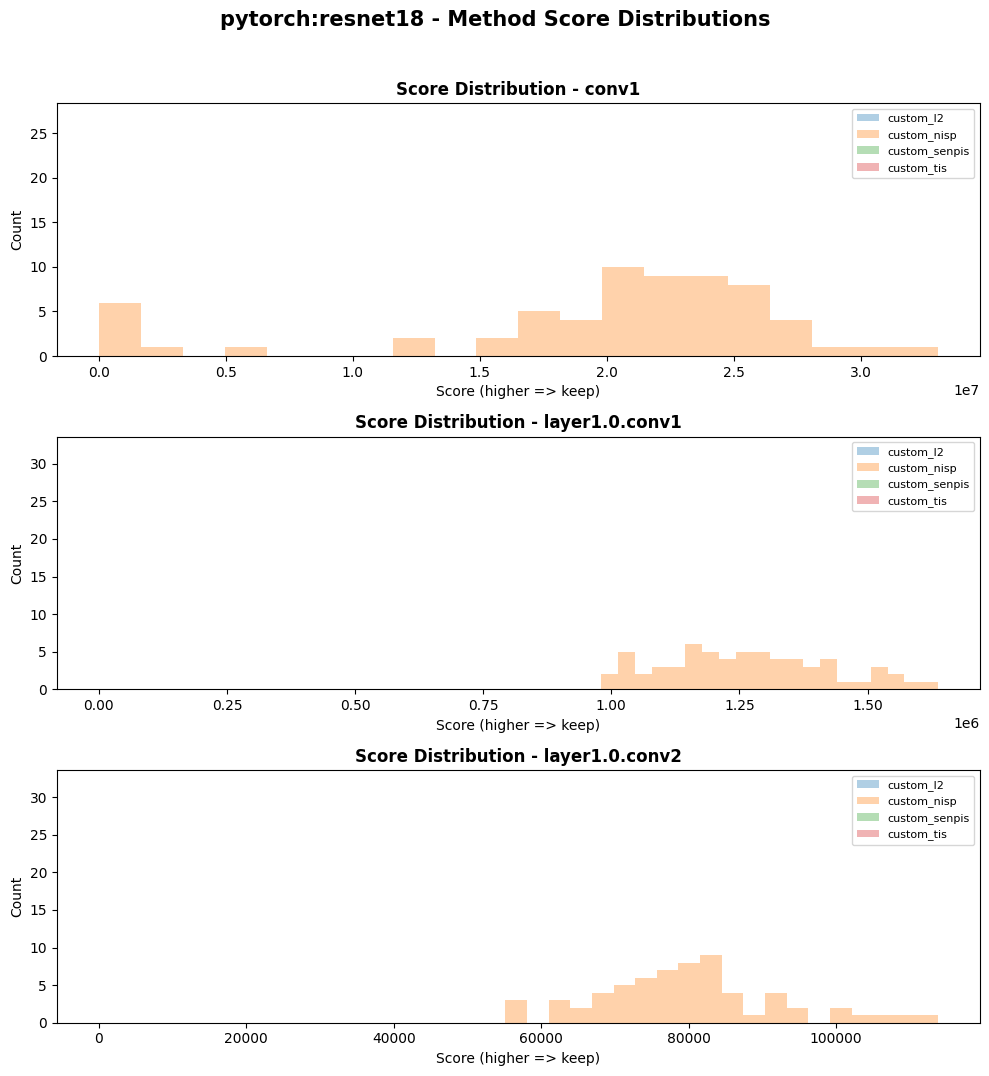

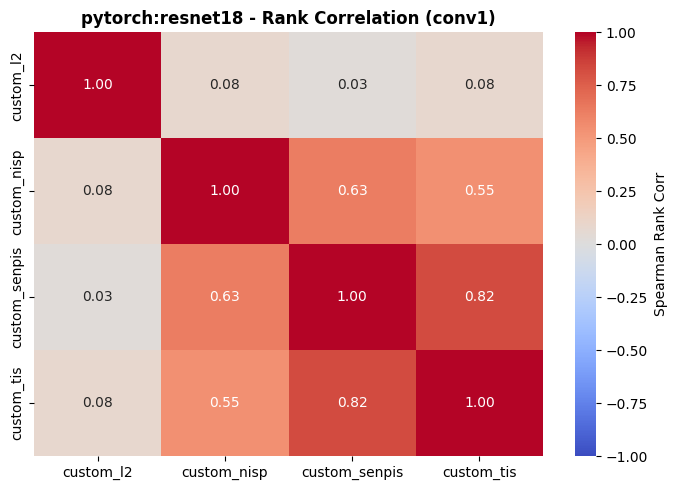

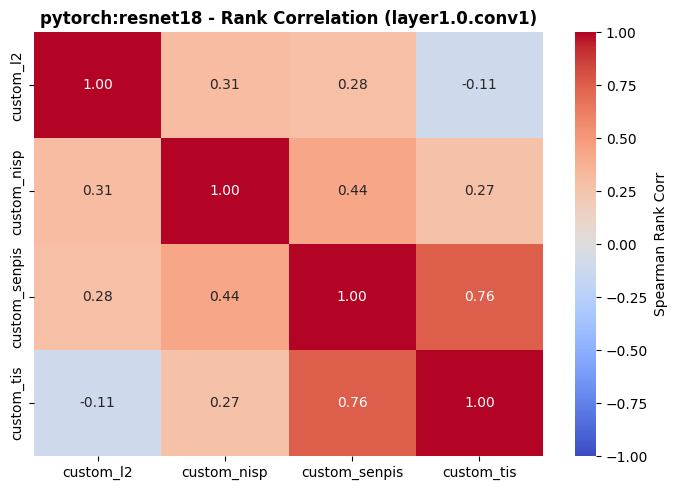

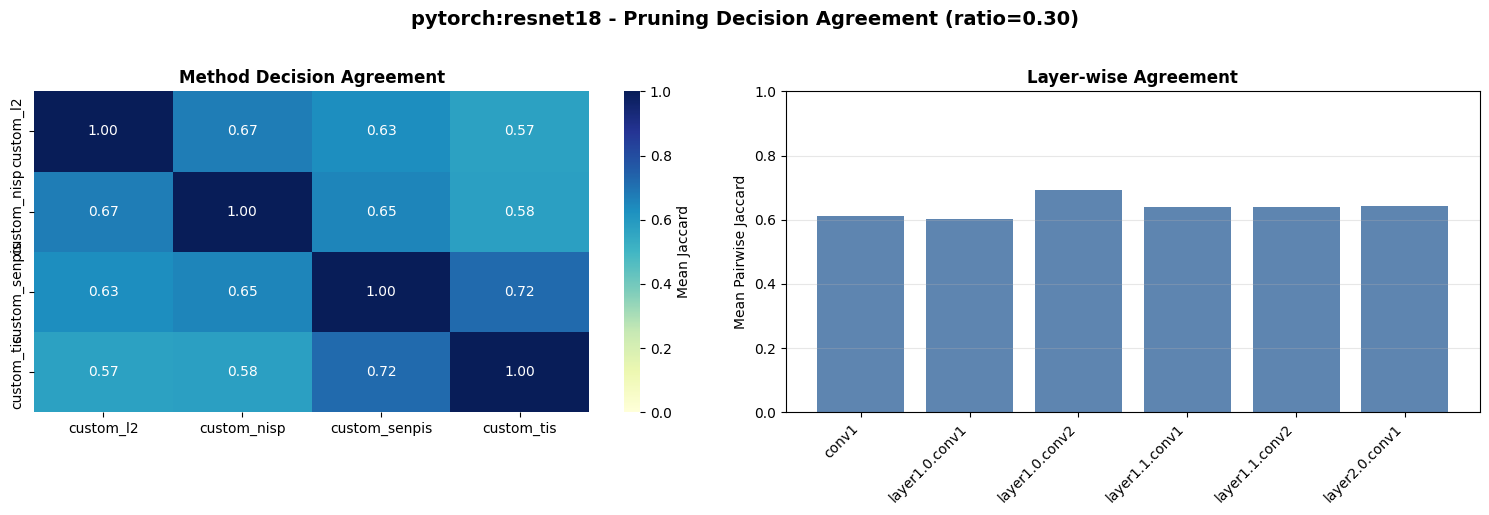

📥 Importing custom pre-trained model...

--- Executing ReduCNN ---
🌐 Analyzing model topology...
✅ Detected residual architecture with 4 pruning clusters.
🔍 Analyzing model using 'custom_nisp' method...
🏗️ Building masks (scope: global, ratio: 0.3)...
✂️ Applying physical surgery...
💾 Saved pruned checkpoint to: saved_models/pruned_raw/pytorch/cifar-10/resnet18/custom_nisp/20260324_112655_pytorch_resnet18_custom_nisp_deep_raw.pth
[timer] prune took 0.32s


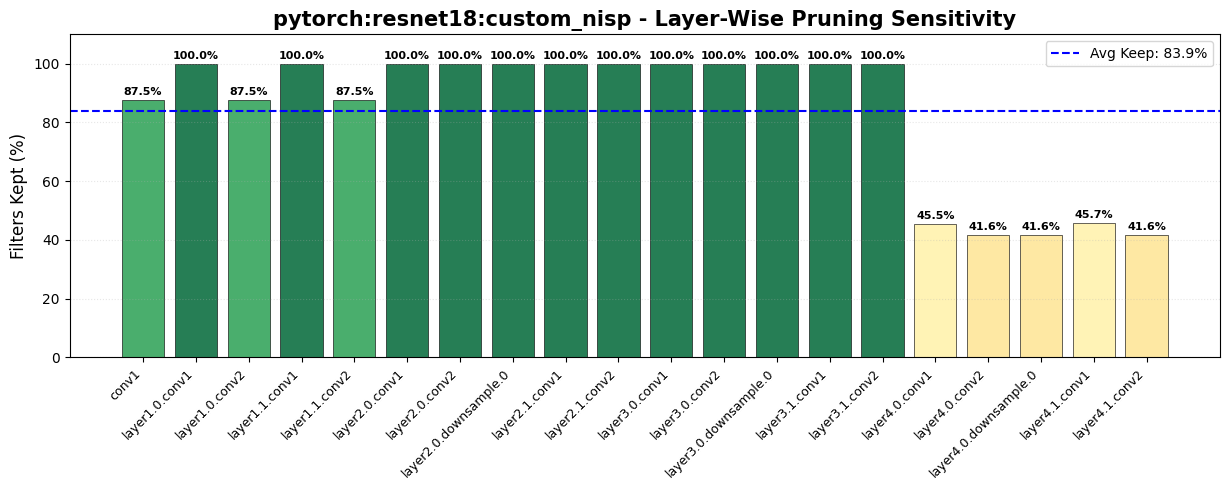

[pytorch_resnet18_custom_nisp_healing] Epoch 1/3: 100%|██████████| 64/64 [00:04<00:00, 15.96it/s, loss=0.1570, acc=94.87%]


[val] Loss 0.1340, Acc 96.70%


[pytorch_resnet18_custom_nisp_healing] Epoch 2/3: 100%|██████████| 64/64 [00:04<00:00, 15.37it/s, loss=0.0346, acc=99.68%]


[val] Loss 0.1130, Acc 97.70%


[pytorch_resnet18_custom_nisp_healing] Epoch 3/3: 100%|██████████| 64/64 [00:04<00:00, 15.38it/s, loss=0.0149, acc=99.98%] 


[val] Loss 0.1071, Acc 97.50%
[train] Restored best validation checkpoint (acc=97.70%).
[timer] train took 13.91s
Saved healed checkpoint: saved_models/fine_tuned/pytorch/cifar-10/resnet18/custom_nisp/20260324_112655_pytorch_resnet18_custom_nisp_healed.pth


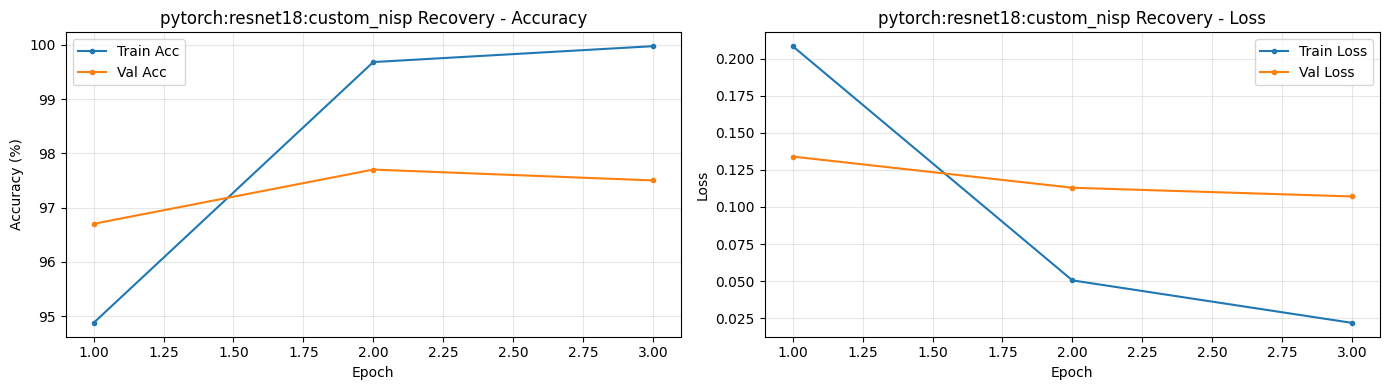

Accuracy Summary:
 - Baseline: 78.50%
 - Pruned:   38.15%
 - Healed:   89.65%

Metrics: Baseline vs Pruned


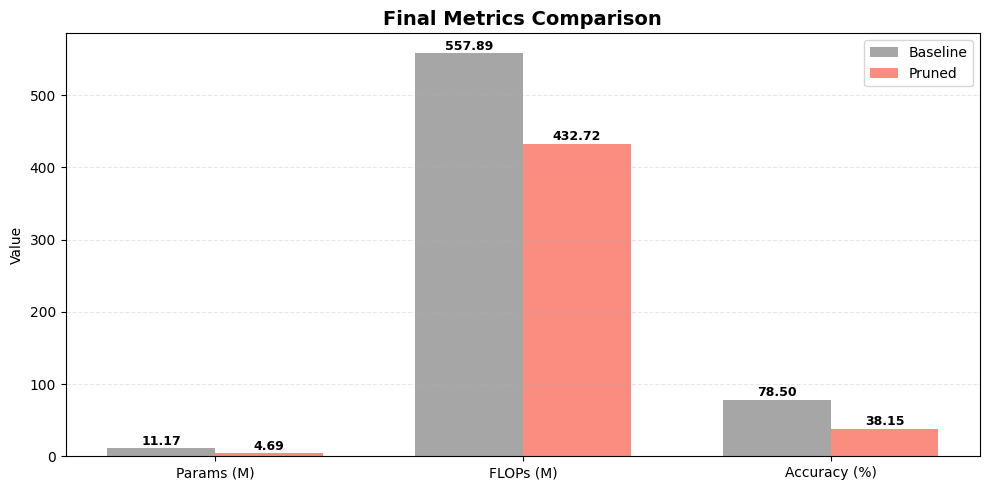

🚀 Business Impact: Model is 1.29x faster (FLOPs reduced by 22.4%).
📉 Accuracy Delta: +40.35%

Metrics: Baseline vs Healed


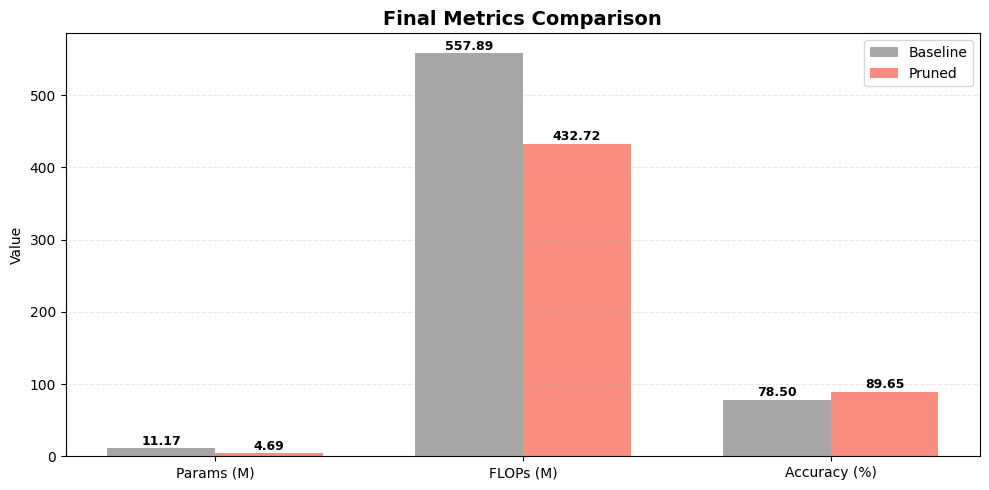

🚀 Business Impact: Model is 1.29x faster (FLOPs reduced by 22.4%).
📉 Accuracy Delta: -11.15%


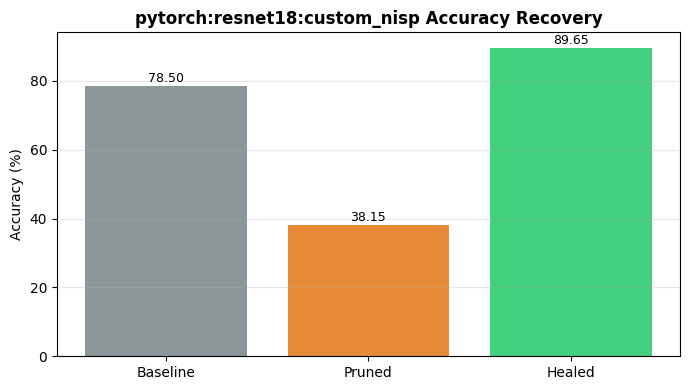

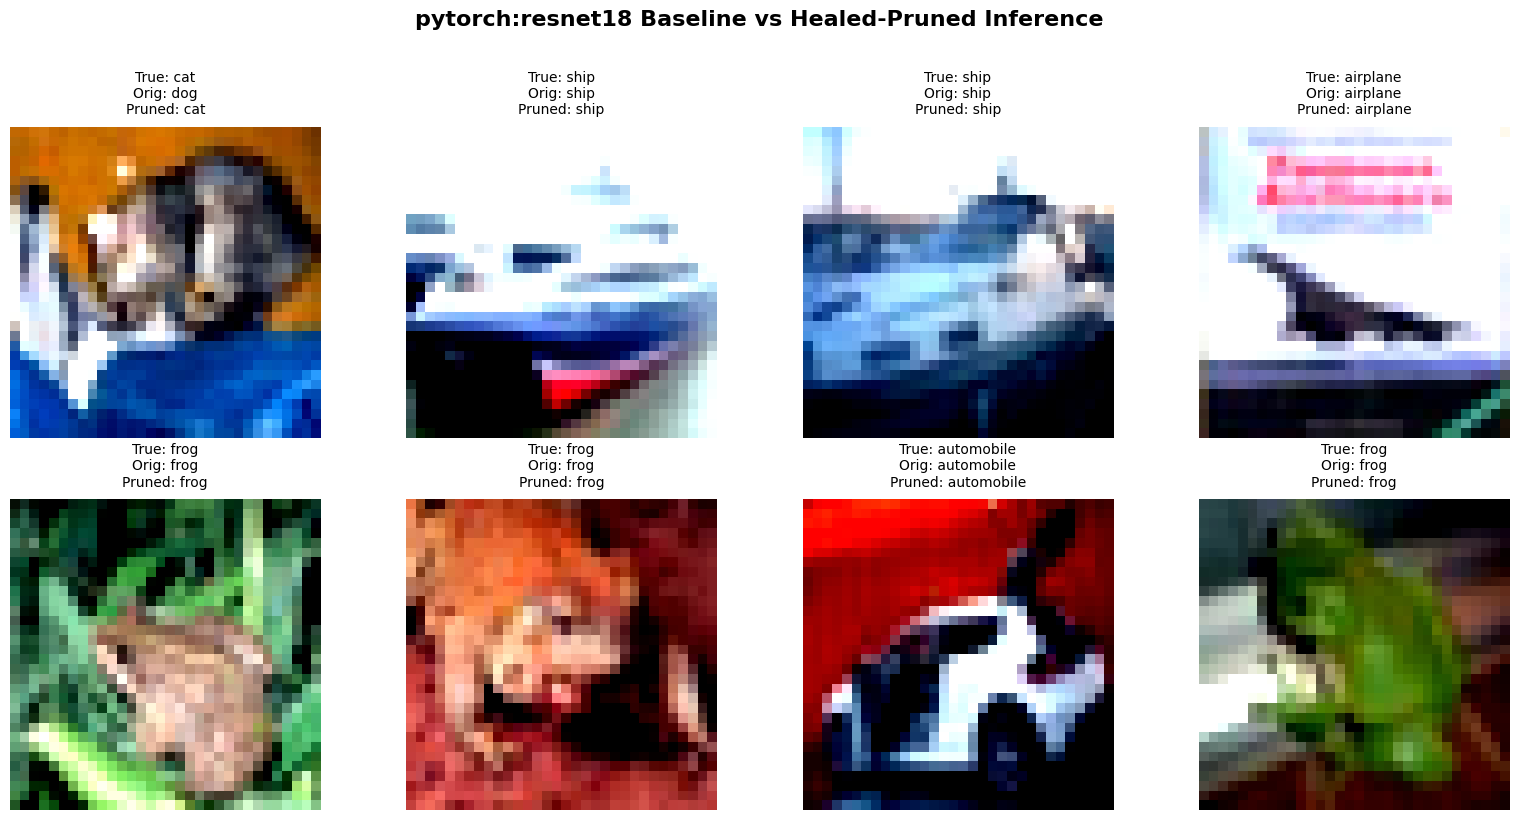


=== Deep Analysis [keras] method=custom_nisp ===


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 126 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Loaded baseline checkpoint: saved_models/baselines/keras/cifar-10/resnet18/20260324_112655_keras_resnet18_baseline.weights.h5


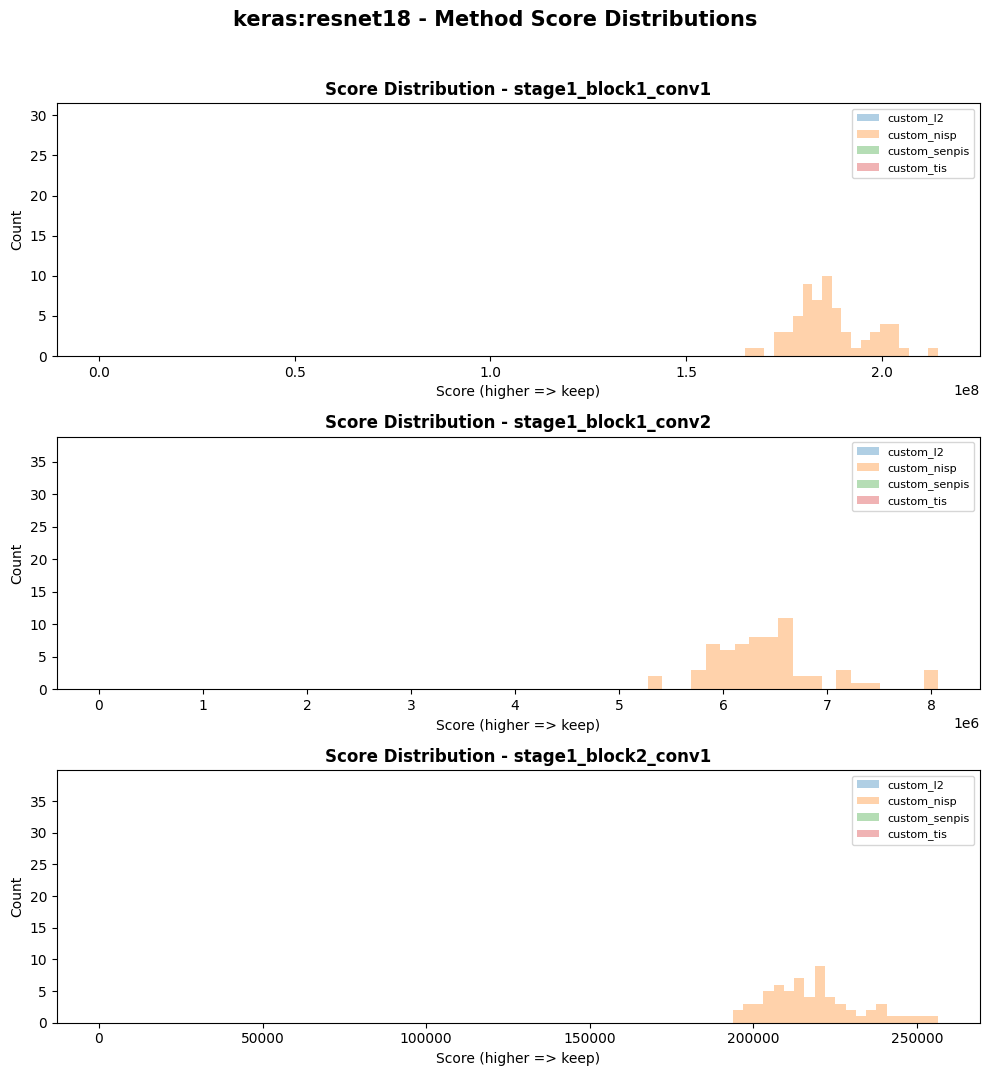

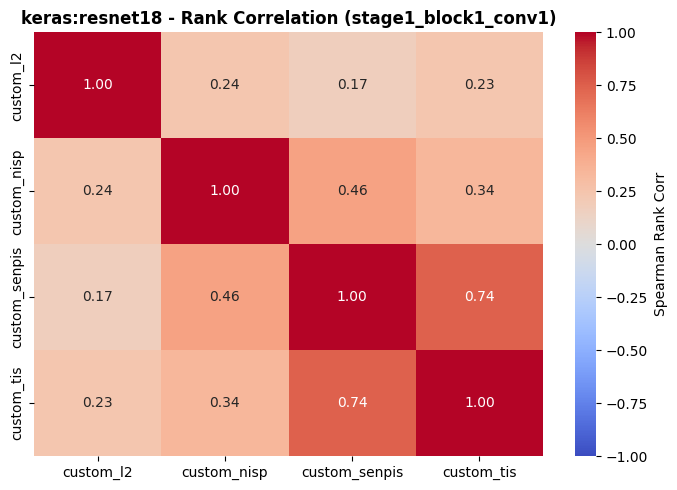

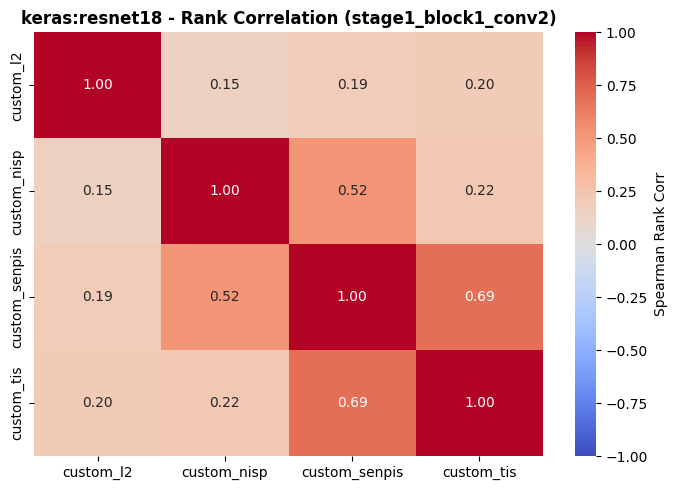

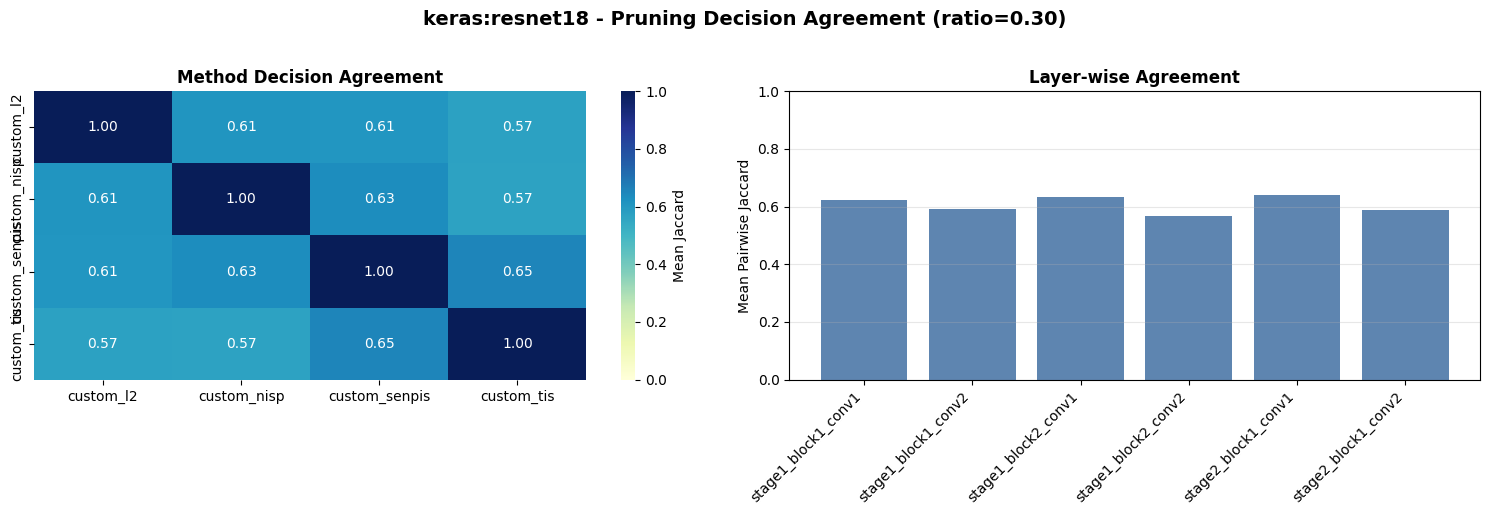

📥 Importing custom pre-trained model...

--- Executing ReduCNN ---
🌐 Analyzing model topology...
✅ Detected residual architecture with 4 pruning clusters.
🔍 Analyzing model using 'custom_nisp' method...
🏗️ Building masks (scope: global, ratio: 0.3)...
✂️ Applying physical surgery...
💾 Saved pruned checkpoint to: saved_models/pruned_raw/keras/cifar-10/resnet18/custom_nisp/20260324_112655_keras_resnet18_custom_nisp_deep_raw.weights.h5
[timer] prune took 1.41s


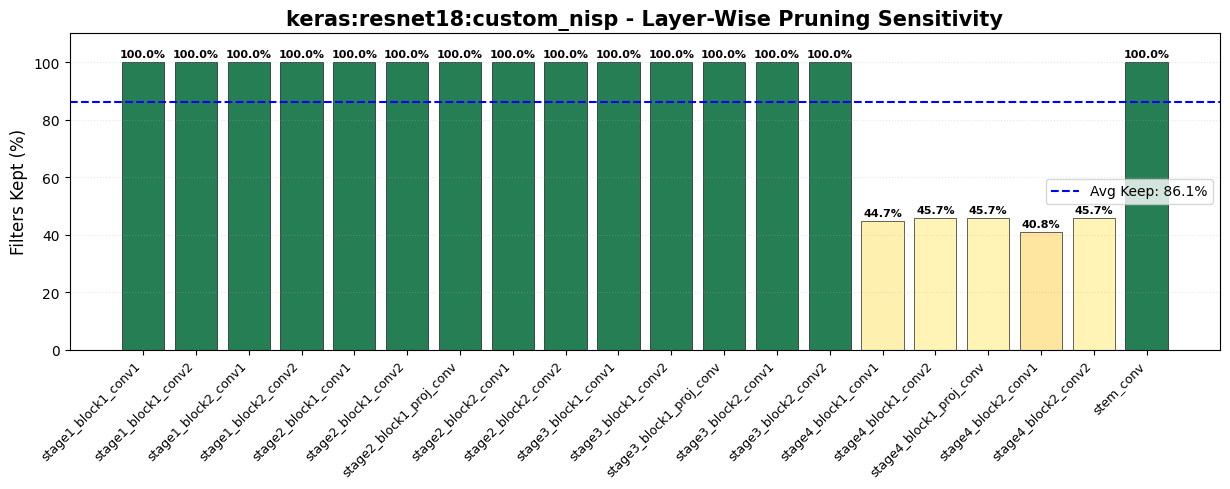

Epoch 1/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9044 - loss: 0.3011[train] Epoch 1/3 - loss: 0.2322 - acc: 0.9290 - val_loss: 0.4650 - val_acc: 0.8730
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 84ms/step - accuracy: 0.9290 - loss: 0.2322 - val_accuracy: 0.8730 - val_loss: 0.4650 - learning_rate: 3.0000e-04
Epoch 2/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9881 - loss: 0.0735[train] Epoch 2/3 - loss: 0.0705 - acc: 0.9868 - val_loss: 0.3075 - val_acc: 0.9180
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.9868 - loss: 0.0705 - val_accuracy: 0.9180 - val_loss: 0.3075 - learning_rate: 3.0000e-04
Epoch 3/3
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9977 - loss: 0.0302[train] Epoch 3/3 - loss: 0.0294 - acc: 0.9983 - val_loss: 0.2671 - val_acc: 0.9220
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.9983 - loss: 0.0294 - val_accuracy: 0.9220 - val_loss: 0.2671 - learning_rate: 3.0000e-04
Restoring model weights from the end of the best epoch: 3.
[timer]

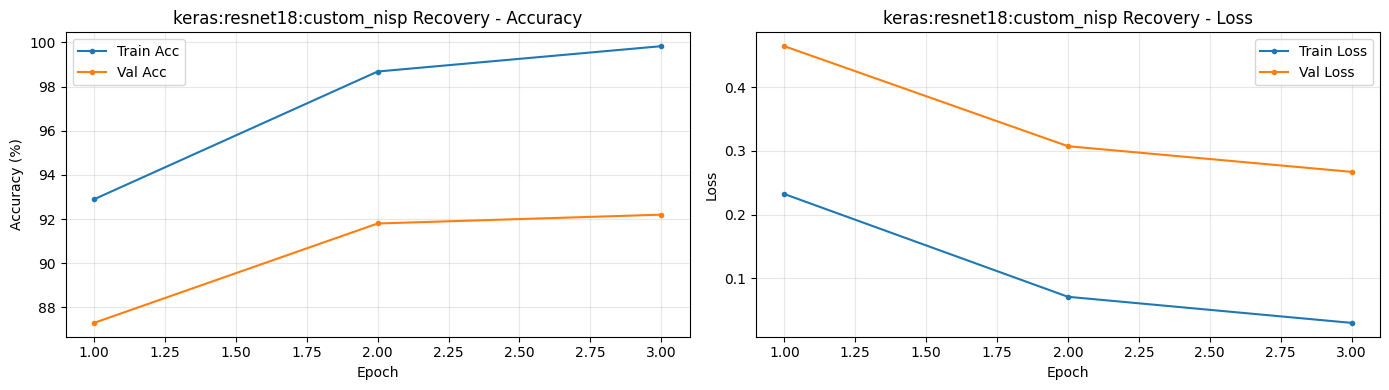

Accuracy Summary:
 - Baseline: 90.75%
 - Pruned:   49.50%
 - Healed:   87.70%

Metrics: Baseline vs Pruned


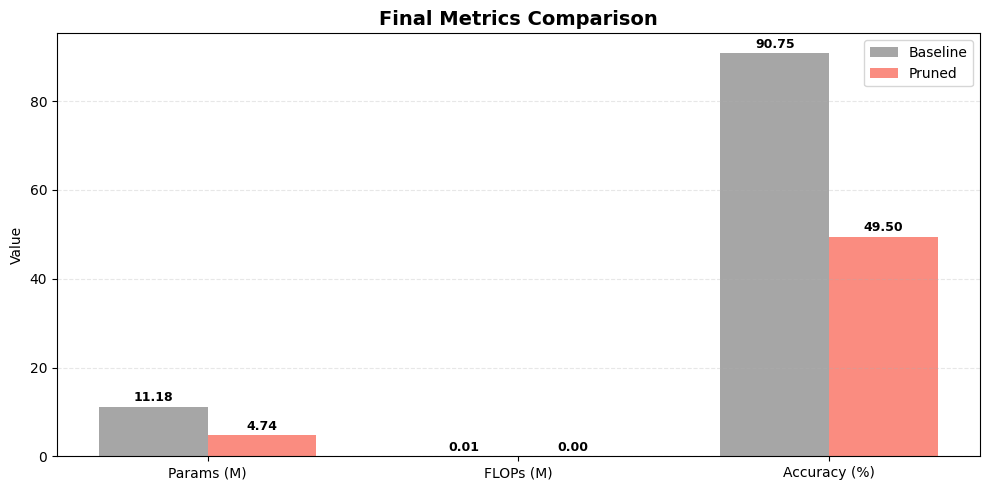

🚀 Business Impact: Model is 2.19x faster (FLOPs reduced by 54.3%).
📉 Accuracy Delta: +41.25%

Metrics: Baseline vs Healed


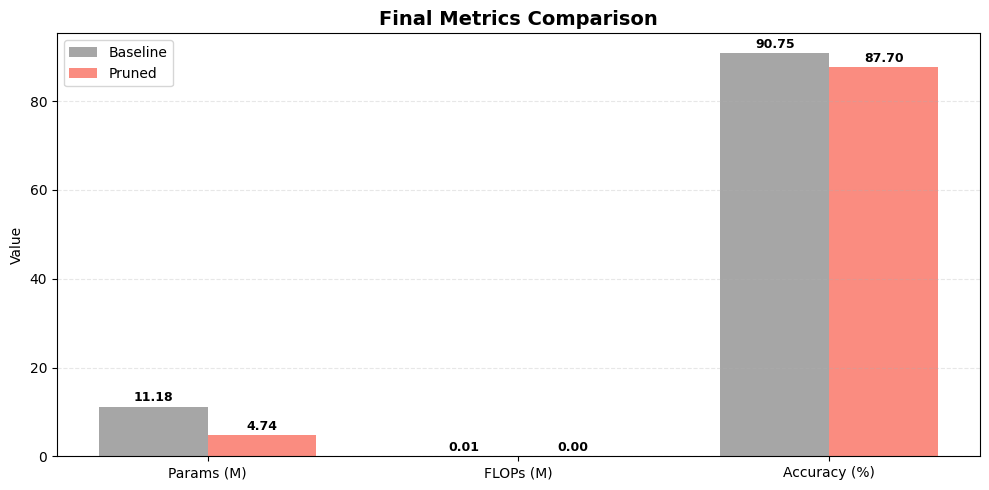

🚀 Business Impact: Model is 2.19x faster (FLOPs reduced by 54.3%).
📉 Accuracy Delta: +3.05%


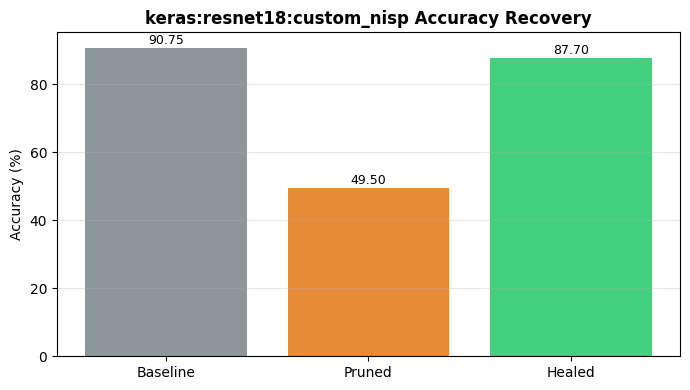

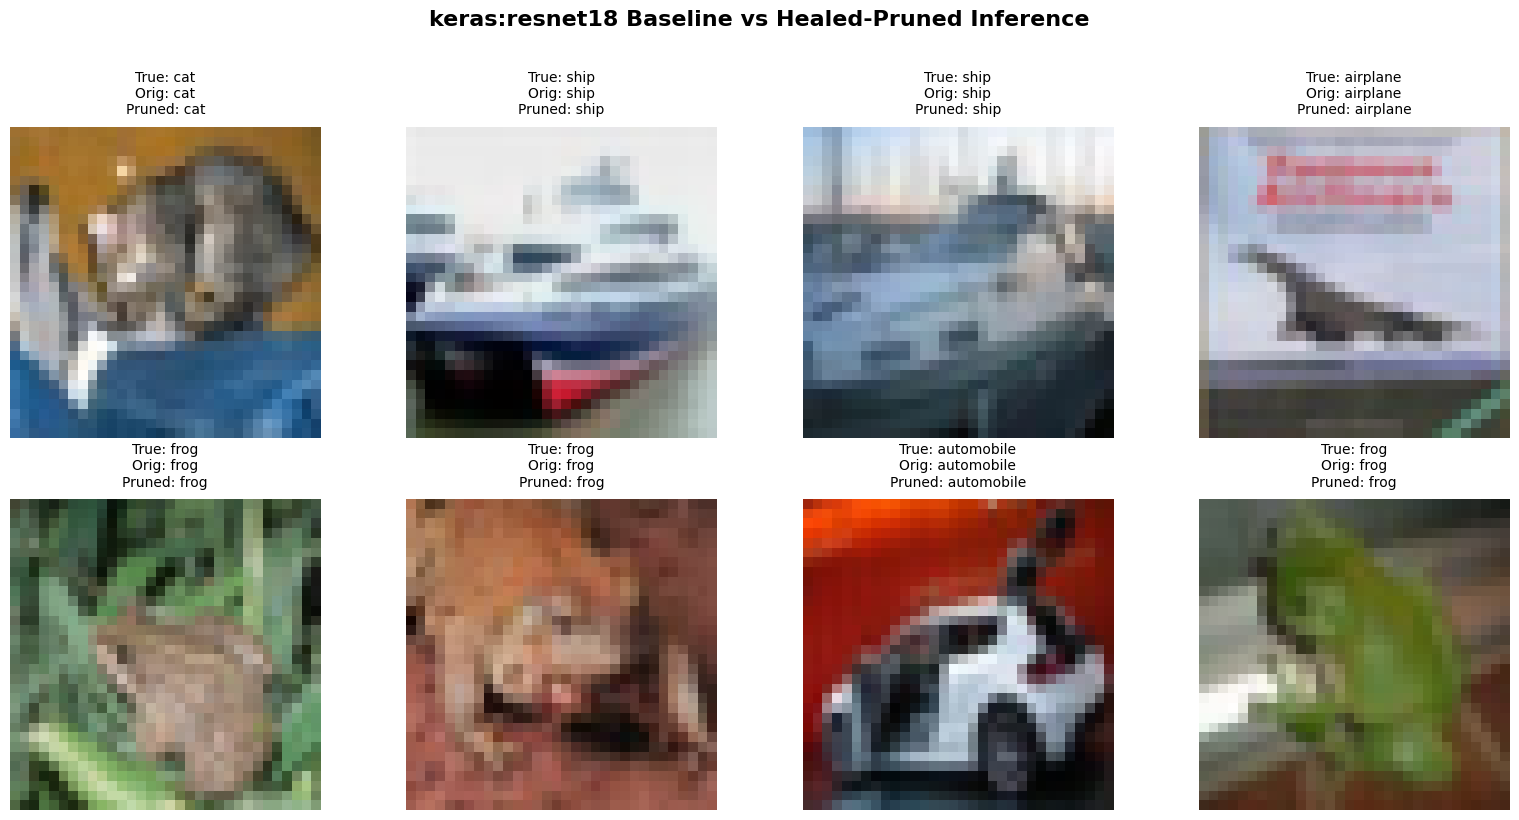

Saved: outputs/custom_method_matrix/deep_analysis_resnet18_custom_nisp_balanced_20260324_112655.csv


,backend,model,method,scope,prune_duration_sec,baseline_acc,pruned_acc,healed_acc,baseline_ckpt_used,raw_pruned_ckpt,healed_ckpt
0,pytorch,resnet18,custom_nisp,global,0.069296,78.500000,38.15,89.650000,saved_models/baselines/pytorch/cifar-10/resnet...,saved_models/pruned_raw/pytorch/cifar-10/resne...,saved_models/fine_tuned/pytorch/cifar-10/resne...
1,keras,resnet18,custom_nisp,global,0.447754,90.750003,49.50,87.699997,saved_models/baselines/keras/cifar-10/resnet18...,saved_models/pruned_raw/keras/cifar-10/resnet1...,saved_models/fine_tuned/keras/cifar-10/resnet1...


In [17]:
# Deep analysis: plots, healing, and baseline-vs-pruned-vs-healed comparison

def _stats_dict(adapter, model, loader, acc):
    flops, params = adapter.get_stats(model, loader)
    return {"FLOPs": float(flops), "Params": float(params), "Acc": float(acc)}


def _plot_accuracy_triplet(b_acc, p_acc, h_acc, title):
    labels = ["Baseline", "Pruned", "Healed"]
    vals = [float(b_acc), float(p_acc), float(h_acc)]
    colors = ["#7f8c8d", "#e67e22", "#2ecc71"]
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(labels, vals, color=colors, alpha=0.9)
    ax.set_ylabel("Accuracy (%)")
    ax.set_title(title, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width() / 2.0, h + 0.2, f"{h:.2f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()


def _safe_score_maps(adapter, model, loader, methods):
    out = {}
    for m in methods:
        try:
            out[m] = adapter.get_score_map(model, loader, m)
        except Exception as e:
            print(f"Skipping score-map method '{m}': {type(e).__name__}: {e}")
    return out


def _run_backend_analysis(backend: str):
    backend = backend.lower().strip()
    if backend == "pytorch":
        if "torch_adapter" not in globals():
            print("PyTorch run cell not executed yet; skipping deep analysis for PyTorch.")
            return None
        adapter = torch_adapter
        model_name = TORCH_MODEL_REQUEST
        calib_loader = torch_loader
        ckpt = torch_ckpt
        train_loader, val_loader, test_loader = make_torch_recovery_loaders()
        cfg = {"backend": "pytorch", "chip_max_spatial": CHIP_MAX_SPATIAL}
        input_shape = (3, 32, 32)
    elif backend == "keras":
        if "keras_adapter" not in globals():
            print("Keras run cell not executed yet; skipping deep analysis for Keras.")
            return None
        adapter = keras_adapter
        model_name = KERAS_MODEL_REQUEST
        calib_loader = keras_loader
        ckpt = keras_ckpt
        train_loader, val_loader, test_loader = make_keras_recovery_loaders()
        cfg = {"backend": "keras", "chip_max_spatial": CHIP_MAX_SPATIAL}
        input_shape = (32, 32, 3)
    else:
        print(f"Unknown backend '{backend}', skipping")
        return None

    print(f"\n=== Deep Analysis [{backend}] method={ANALYSIS_METHOD} ===")

    baseline = adapter.get_model(model_name, input_shape=input_shape, num_classes=10, pretrained=False)
    if ckpt:
        adapter.load_checkpoint(baseline, ckpt)
        print(f"Loaded baseline checkpoint: {ckpt}")

    baseline_acc = float(adapter.evaluate(baseline, test_loader))

    score_maps = _safe_score_maps(adapter, baseline, calib_loader, ANALYSIS_COMPARE_METHODS)
    if score_maps:
        plot_score_distributions(score_maps, title_prefix=f"{backend}:{model_name}")
        if len(score_maps) >= 2:
            plot_rank_correlation(score_maps, title_prefix=f"{backend}:{model_name}")
            plot_decision_agreement(score_maps, ratio=PRUNE_RATIO, title_prefix=f"{backend}:{model_name}")

    scope = "global" if ANALYSIS_METHOD in GLOBAL_METHODS else "local"
    pruner = ReduCNNPruner(method=ANALYSIS_METHOD, scope=scope, config=cfg)

    raw_ckpt = build_checkpoint_path(
        stage="pruned_raw",
        backend=backend,
        model_name=model_name,
        method=ANALYSIS_METHOD,
        suffix="deep_raw",
        run_stamp=RUN_STAMP,
    ) if SAVE_RAW_PRUNED_CHECKPOINTS else None

    pruned_model, masks, prune_duration = pruner.prune_custom_model(
        baseline,
        calib_loader,
        ratio=PRUNE_RATIO,
        save_pruned_path=raw_ckpt,
    )

    pruned_acc = float(adapter.evaluate(pruned_model, test_loader))
    plot_layer_sensitivity(masks, title_prefix=f"{backend}:{model_name}:{ANALYSIS_METHOD}")

    history = adapter.train(
        pruned_model,
        train_loader,
        epochs=FINETUNE_EPOCHS,
        val_loader=val_loader,
        name=f"{backend}_{model_name}_{ANALYSIS_METHOD}_healing",
        plot=False,
    )

    healed_ckpt = ""
    if SAVE_HEALED_CHECKPOINTS:
        healed_ckpt = build_checkpoint_path(
            stage="fine_tuned",
            backend=backend,
            model_name=model_name,
            method=ANALYSIS_METHOD,
            suffix="healed",
            run_stamp=RUN_STAMP,
        )
        adapter.save_checkpoint(pruned_model, healed_ckpt)
        print(f"Saved healed checkpoint: {healed_ckpt}")

    healed_acc = float(adapter.evaluate(pruned_model, test_loader))
    plot_training_history(history, title=f"{backend}:{model_name}:{ANALYSIS_METHOD} Recovery")

    baseline_stats = _stats_dict(adapter, baseline, test_loader, baseline_acc)
    pruned_stats = _stats_dict(adapter, pruned_model, test_loader, pruned_acc)
    healed_stats = _stats_dict(adapter, pruned_model, test_loader, healed_acc)

    print("Accuracy Summary:")
    print(f" - Baseline: {baseline_acc:.2f}%")
    print(f" - Pruned:   {pruned_acc:.2f}%")
    print(f" - Healed:   {healed_acc:.2f}%")

    print("\nMetrics: Baseline vs Pruned")
    plot_metrics_comparison(baseline_stats, pruned_stats)
    print("\nMetrics: Baseline vs Healed")
    plot_metrics_comparison(baseline_stats, healed_stats)

    _plot_accuracy_triplet(
        baseline_acc,
        pruned_acc,
        healed_acc,
        title=f"{backend}:{model_name}:{ANALYSIS_METHOD} Accuracy Recovery",
    )

    try:
        plot_inference_gallery(
            baseline,
            pruned_model,
            test_loader,
            num_images=8,
            class_names=CLASS_NAMES,
            title=f"{backend}:{model_name} Baseline vs Healed-Pruned Inference",
        )
    except Exception as e:
        print(f"Inference gallery skipped: {type(e).__name__}: {e}")

    return {
        "backend": backend,
        "model": model_name,
        "method": ANALYSIS_METHOD,
        "scope": scope,
        "prune_duration_sec": float(prune_duration),
        "baseline_acc": float(baseline_acc),
        "pruned_acc": float(pruned_acc),
        "healed_acc": float(healed_acc),
        "baseline_ckpt_used": ckpt or "",
        "raw_pruned_ckpt": raw_ckpt or "",
        "healed_ckpt": healed_ckpt or "",
    }


analysis_records = []
if RUN_DEEP_ANALYSIS:
    for b in ANALYSIS_BACKENDS:
        rec = _run_backend_analysis(b)
        if rec is not None:
            analysis_records.append(rec)

analysis_df = pd.DataFrame(analysis_records)
if not analysis_df.empty:
    report_dir = Path("outputs/custom_method_matrix")
    report_dir.mkdir(parents=True, exist_ok=True)
    analysis_path = report_dir / f"deep_analysis_{MODEL_TARGET}_{ANALYSIS_METHOD}_{EXPERIMENT_PRESET}_{RUN_STAMP}.csv"
    analysis_df.to_csv(analysis_path, index=False)
    print("Saved:", analysis_path)

analysis_df


## Notes

- Normal user workflow: define method math + `@register_method(...)`; backend handles most heavy lifting.
- Real-run quality is controlled by `EXPERIMENT_PRESET`.
- `chip` is computationally expensive, especially on deeper models.
- Deep analysis section adds:
  - layer sensitivity plots
  - score/rank/decision method comparisons
  - healing (fine-tuning) curves
  - baseline vs pruned vs healed metric comparison
  - inference gallery comparison
